# __Métodos Probabilísticos__:
<font size=3>

Os **métodos probabilísticos** em Aprendizado de Máquina são abordagens que utilizam a Teoria das Probabilidades e Estatística para **modelar incertezas**, **inferir padrões** e **tomar decisões** a partir de dados. Esses métodos *assumem que os dados são gerados por algum processo estocástico (aleatório)*, e tentam modelar explicitamente as distribuições de probabilidade envolvidas.

Na modelagem estatística, os dados são interpretados como **amostras provenientes de distribuições de probabilidade**. Por exemplo, *ao analisarmos os atributos das flores de íris, visualizamos suas distribuições por meio de histogramas*.

<font size=3><center>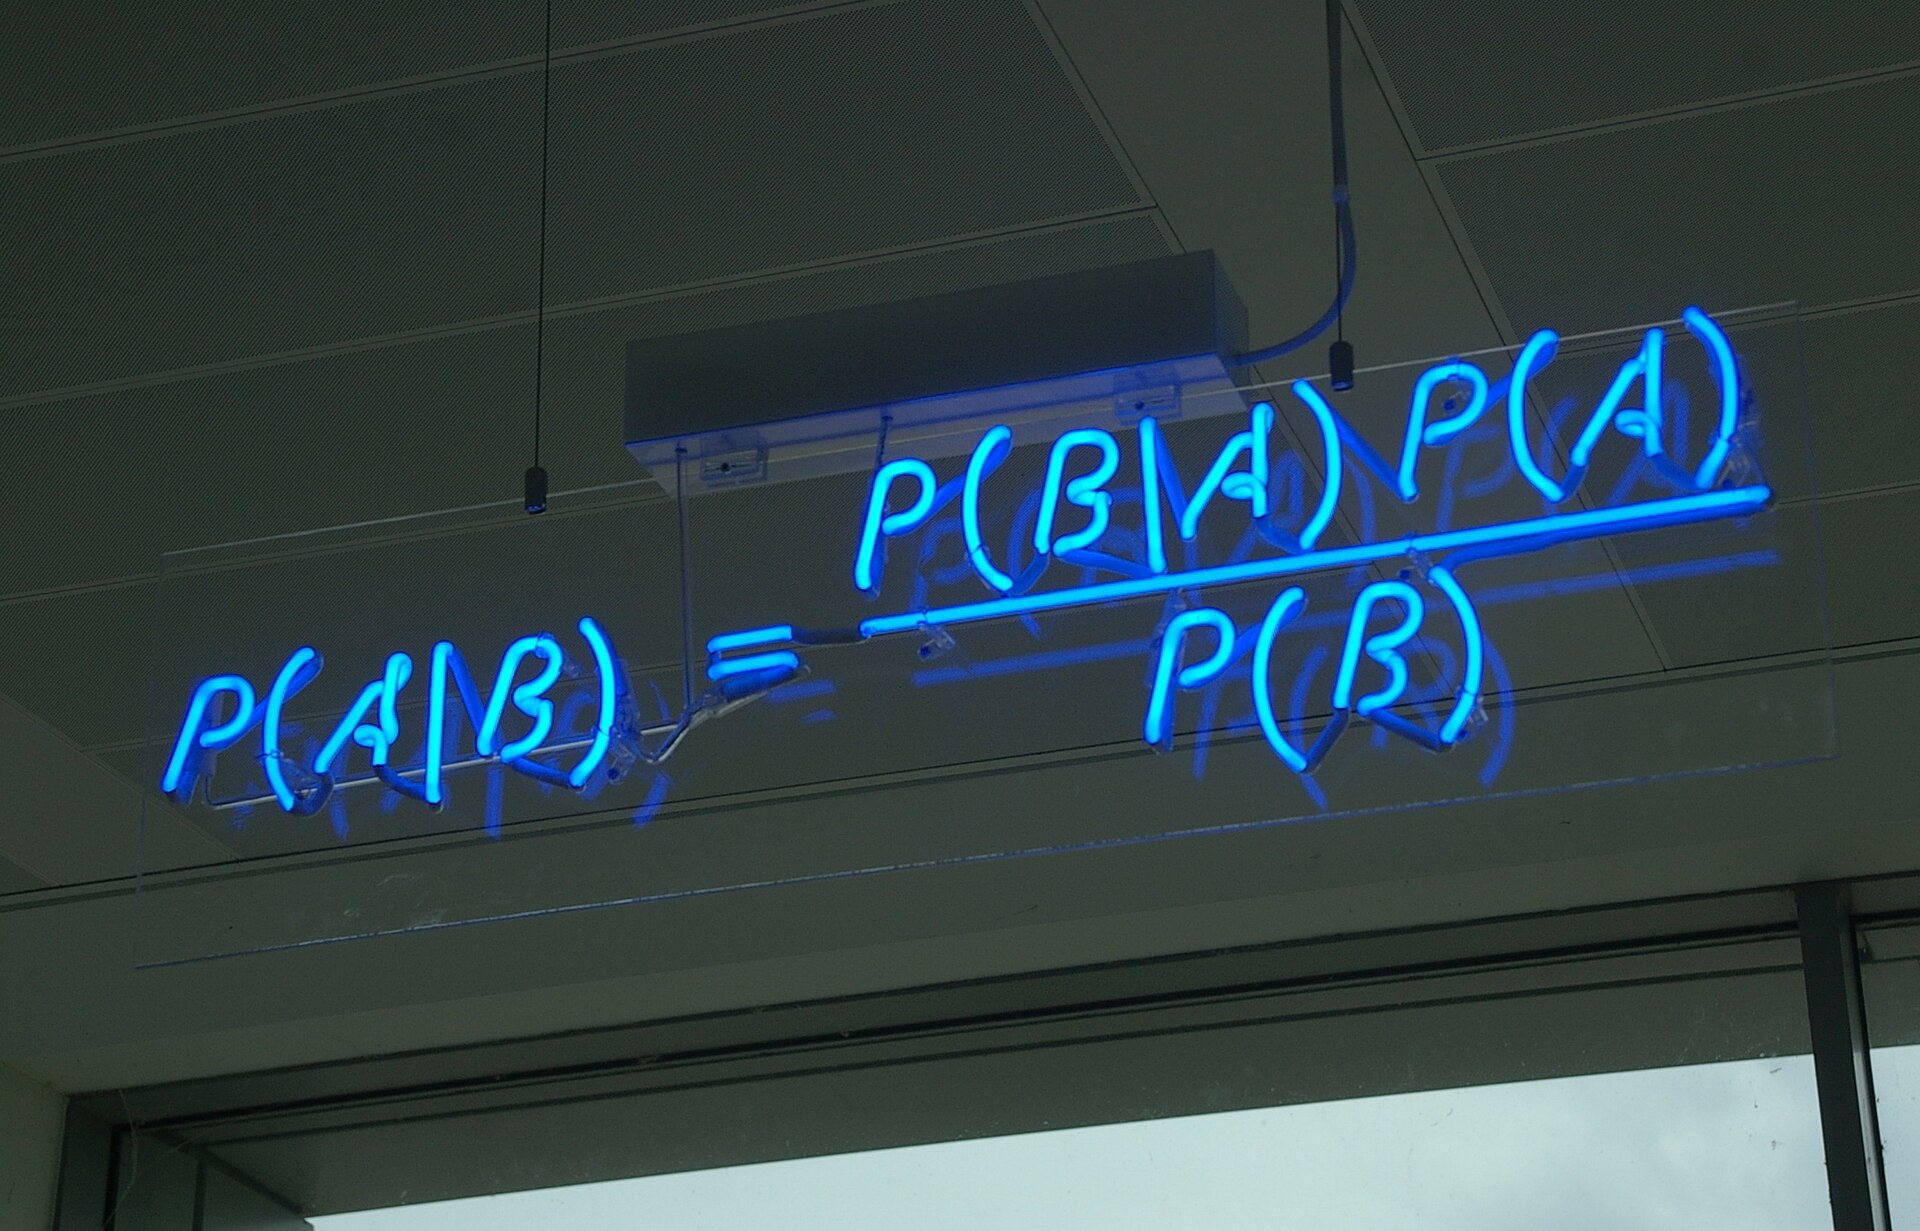</center>

## __1. O Teorema de Bayes:__
<font size=3>

O [Teorema de Bayes](https://pt.wikipedia.org/wiki/Teorema_de_Bayes) é um princípio fundamental da Estatística que descreve *como atualizar a __probabilidade de uma hipótese $H$ com base em novas evidências $E$__*. Ele estabelece uma relação entre a __probabilidade *a priori*__ (antes da observação dos dados) e a __probabilidade *a posteriori*__ (após observar os dados), levando em conta a [verossimilhança](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_de_verossimilhan%C3%A7a) (*likelihood*) das evidências sob a hipótese considerada. Em outras palavras, o teorema mostra como "rever" nossas crenças à medida que novas informações são adquiridas.

<font size=3>

Na sua formulação, temos
$$
    P(H \mid E) = \frac{P(E \mid H) \cdot P(H)}{P(E)}
$$
onde,
- **$P(H \mid E)$**: probabilidade da hipótese $H$ ser verdadeira dadas evidências $E$ &mdash; chamada de **probabilidade posterior (_a posteriori_)**;
- **$P(E \mid H)$**: probabilidade de observar as evidências $E$ se a hipótese $H$ for verdadeira &mdash; **verossimilhança**;
- **$P(H)$**: probabilidade **_a priori_** da hipótese $H$ &mdash; **conhecimento prévio**;
- **$P(E)$**: probabilidade dos dados &mdash; **fator de normalização (evidência)**.

### __1.1 Aprendizado Bayesiano:__
<font size=3>

Como a **Estatística Bayesiana** se aplica ao **Aprendizado de Máquina**? Aqui, iremos considerar a hipótese $H$ como a **predição do modelo** (_e.g._, a predição $\hat y$ dos dados de teste), e as evidências $E$ como os **dados dos atributos** (dados $X$ de treinamento). Considerando o conjunto de *dados de flores de íris*, as distribuições de probabilidade do Teorema de Bayes ficam:
$$
    P(\text{classe} \mid \text{atributos}) = \frac{P(\text{atributos} \mid \text{classe}) \cdot P(\text{classe})}{P(\text{atributos})}
$$

- **_A posteriori_ - $P(\text{classe} \mid \text{atributos})$:** é a probabilidade da flor pertencer a uma determinada espécie (classe), dado que observamos suas características (atributos).

- **Verossimilhança - $P(\text{atributos} \mid \text{classe})$:** é a probabilidade de observar esses atributos, dado que a flor pertence a uma certa espécie, _e.g._, *qual a chance de uma flor ter 5.1 cm de pétala se for da espécie versicolor?*  

- **_A priori_ - $P(\text{classe})$:** é a probabilidade de cada classe antes de observar os dados. Neste caso, podemos assumir que todas as classes têm a mesma probabilidade (1/3), mas se o conjunto estiver **desbalanceado**, podemos usar a frequência relativa das classes como a distribuição _a priori_.

- **Evidência - $P(\text{atributos})$:** é a probabilidade de observar aquelas características, independentemente da classe. Usualmente não calculamos diretamente esse termo, pois podemos apenas fazer,
$$
    P(\text{setosa} \mid \mathbf{X}) = Norm\left[P(\mathbf{X} \mid \text{setosa}) \cdot P(\text{setosa})\right] \in [0,\, 1] \, ,
$$
onde os atributos seriam, por exemplo,
$$
    \mathbf{X} = [\text{comprimento-pétala 1.4 cm},\, \text{comprimento-sépala 5.1 cm},\, \text{largura-pétala 0.2 cm},\, \text{largura-sépala 3.5 cm}]\, .
$$

## __2. O classificador Naive Bayes:__
<font size=3>

O método de classificação **Naive Bayes** (NB) é uma abordagem de aprendizado baseado no Teorema de Bayes, que assume de forma simplificada (ou "*ingênua*") que **todas as variáveis preditoras são independentes entre si** (um atributo não influencia o outro).

<font size=3>

Essa afirmação é expressa da seguinte forma,  
$$
    P(X_1,\, X_2,\, \dots,\, X_n \mid y) = P(X_1 \mid y) \cdot P(X_2 \mid y) \cdot \dots \cdot P(X_n \mid y) \, ,
$$  
ou seja,
> *a probabilidade conjunta dos atributos dada a classe $y$ é o produto das probabilidades individuais*.

Apesar dessa suposição **muitas vezes não refletir a realidade**, o Naive Bayes é amplamente utilizado por sua simplicidade e bom desempenho em tarefas de classificação.
O método calcula a probabilidade de uma determinada amostra pertencer a uma classe com base na frequência dos atributos observados, sendo especialmente eficaz quando aplicado a **grandes volumes de dados** com **alta dimensionalidade**.

> **Observação:** o método Naive Bayes **não** é utilizado em tarefas de regressão, pois seu objetivo é somente apontar a classe mais provável dado uma entrada de atributos.


### __2.1 Matemática e algoritmo:__
<font size=3>

Dado um conjunto de atributos $\mathbf{X}$ associados às classes $y_k$, temos
$$
    P\left(y_k \mid \mathbf{X}\right) \;\propto\; P\left(\mathbf{X} \mid y_k\right) \cdot P\left(y_k\right) \, .
$$
Usando a definição de **independência entre variáveis**, podemos calcular a classe $\hat y$ de probabilidade máxima dentre as $y_k$ (dado os $n$ atributos $X_i$),
$$
    \hat{y} = \arg\max_{y_k} \left[ P(y_k) \prod_{i=1}^n P\left(X_i \mid y_k\right) \right] \, .
$$

<font size=3>
    
O **algoritmo** Naive Bayes segue:
 - **Para a fase de treinamento**:
 1. **Calcular a probabilidade _a priori_** de cada classe $P(y_k)$, com base na frequência das classes no conjunto de dados.
    
 2. **Calcular verossimilhança** $P\left(X_i \mid y_k\right)$ para cada atributo $X_i$ dado cada classe $y_k$:
    - Para **atributos categóricos**: conta a frequência relacionado a cada classe.
    - Para **atributos contínuos**: geralmente se assume uma distribuição normal (*Naive Bayes Gaussiano*), e estima-se a média e variância para cada atributo em cada classe (exemplo na próxima seção).
    <br>

 - **Para a fase de predição:**
 1. Dada uma *nova amostra* $\mathbf{X} = (X_1,\, X_2,\, \dots,\, X_n)$, calcular a probabilidade de cada classe usando a expressão de $\hat y$ descrita acima.

 2. Escolhe a classe com a maior probabilidade como o rótulo previsto.

      

### __2.2 Exemplo com íris:__
<font size=3>

Como as medidas de pétalas e sépalas são atributos contínuos, o método considera uma distribuição Gaussiana da verossimilhança, a probabilidade de se terem *tais medidas* ($X_i$) dado a classe $y_k$,
$$
    P\left(X_i \mid y_k\right) = \frac{1}{\sqrt{2\pi\sigma_{k,i}^2}}\exp\left[-\frac{\left(X_i-\mu_{k,i}\right)^2}{2\sigma_{k,i}^2}\right] \, ,
$$
onde $X_i$ é o valor do atributo $i$; $\mu_{k,i}$ é a média do atributo $i$ na classe $y_k$; e $\sigma_{k,i}^2$ é a variância do atributo $i$ na classe $y_k$.

- **No treinamento** o algoritmo armazena:
    1. As probabilidades _a priori_ $P(y_k)$ de cada classe;
    2. E os valores de $\mu_{k,i}$ e $\sigma_{k,i}^2$ de cada atributo $X_i$.
    <br>

- **Na predição** o algoritmo, ao calcular $P(y_k)\cdot \prod_{i=1}^n P(X_i\mid y_k)$, utiliza os parâmetros $\mu_{k,i}$ e $\sigma_{k,i}^2$ do treinamento para estimar $P(X_i\mid y_k)$. Em seguida, define a classe de maior probabilidade $\hat y$ (*argumento máximo*).

<br>

Vamos resolver o problema de classificação de *flores de íris* usando [`GaussianNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) do Scikit-Learn.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
# importando os dados:
X, y = load_iris(return_X_y=True)

# dividindo os dados entre treinamento e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# definindo o método gaussiano Naive Bayes:
model = GaussianNB()

# treinando o modelo:
model.fit(X_train, y_train)

# realizando predições e avaliação:
y_pred = model.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}")

Acurácia: 0.978


### **2.3 Outras distribuições:**
<font size=3>

O `scikit-learn` oferece outras implementações do Naive Bayes, cada uma otimizada para um tipo diferente de dado. Vamos conhecer elas.

#### **2.3.1 Multinomial NB:**
<font size=3>
    
* **Quando usar?** É a escolha ideal para dados que representam **contagens ou frequências**, como dados de texto ou tabelas de contagem de genes.

* **Fórmula da Verossimilhança:** A probabilidade do atributo $i$ (e.g., uma palavra específica) ser observada na classe $y_k$ é estimada pela frequência relativa suavizada:
$$
    P(X_i \mid y_k) = \frac{N_{ki} + \alpha}{N_k + \alpha \cdot n} \, ,
$$
    onde,
    * $N_{ki}$ é a contagem total do atributo $i$ nas amostras da classe $y_k$.
    * $N_k$ é a contagem total de todos os atributos na classe $y_k$.
    * $\alpha$ é um hiperparâmetro de suavização (geralmente $\alpha = 1$, conhecido como suavização de Laplace), que evita probabilidades nulas para atributos não vistos no treinamento.
    * $n$ é o número total de atributos únicos (e.g., o tamanho do vocabulário).
    <br>

* **Exemplo de aplicação:**
    * Filtros de spam, baseados na frequência das palavras.
    * Classificação de artigos de notícia em categorias como "Esportes", "Política", etc.

#### **2.3.2 Bernoulli NB:**
<font size=3>

* **Quando usar?** Quando seus atributos forem **binários** (zeros e uns), representando a presença ou ausência de uma característica.

* **Fórmula da Verossimilhança:** Ele calcula a probabilidade do atributo $i$ estar presente em uma amostra da classe $y_k$:

$$
P(X_i=1 \mid y_k) = \frac{N_{ki} + \alpha}{N_k + 2\alpha} \, ,
$$
onde,
* $N_{ki}$ é o número de amostras da classe $y_k$ onde o atributo $i$ está presente.
* $N_k$ é o número total de amostras na classe $y_k$.
* $\alpha$ é o hiperparâmetro de suavização.
A probabilidade do atributo estar ausente é simplesmente $P(X_i=0 \mid y_k) = 1 - P(X_i=1 \mid y_k)$.
<br>

* **Exemplo de aplicação:**
    * Classificação de texto onde o foco é apenas a presença de palavras-chave, e não quantas vezes elas aparecem.
      

#### **2.3.3 Categorical NB:**
<font size=3>
    
* **Quando usar?** É a ferramenta certa quando os seus atributos são **categóricos e discretos** (não necessariamente binários).

* **Fórmula da Verossimilhança:** A probabilidade do atributo $i$ ter uma categoria específica $t$ dentro da classe $y_k$ é:
$$
P(X_i=t \mid y_k) = \frac{N_{kit} + \alpha}{N_k + \alpha \cdot c_i} \, ,
$$
    onde,
    * $N_{kit}$ é o número de amostras da classe $y_k$ onde o atributo $i$ tem a categoria $t$.
    * $N_k$ é o número total de amostras na classe $y_k$.
    * $\alpha$ é o hiperparâmetro de suavização.
    * $c_i$ é o número total de categorias disponíveis para o atributo $i$.
    <br>

* **Exemplo de aplicação:**
    * Classificar cogumelos como "comestíveis" ou "venenosos" com base em atributos como "cor do chapéu", "formato" e "habitat".

#### **2.3.4 Resumo:**
<font size=3>
    
| Modelo Scikit-learn | Tipo de Atributo Ideal | Exemplo de Uso |
| :--- | :--- | :--- |
| **`GaussianNB`** | Contínuo (decimal, float) | Medidas de sensores, dados biométricos |
| **`MultinomialNB`** | Contagem/Frequência (inteiro) | Contagem de palavras em textos |
| **`BernoulliNB`** | Binário (0 ou 1) | Presença/Ausência de uma palavra |
| **`CategoricalNB`** | Categórico (discreto) | Cor, tipo, região |

## __Referências:__
<font size=3>

- **(5.1 - 5.2)**: K. Faceli, _Inteligência artificial: uma abordagem de aprendizado de máquina_. Grupo Gen - LTC, 2011.
  